<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #1f2937 45%, #334155 100%);
  padding: 16px 20px;
  border-radius: 14px;
  text-align: center;
  box-shadow: 0 12px 30px rgba(0,0,0,.35);
  font-family: Arial, sans-serif;
  margin: 0;
">
Clasificacion de imagenes - Perros y gatos
</h1>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Librerias
</h2>

In [ ]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras.models import Sequential, load_model, Model # type: ignore
from tensorflow.keras.layers import ( # type: ignore
    Input, Conv2D, MaxPool2D, Flatten, Dense,
    GlobalAveragePooling2D, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # type: ignore
from tensorflow.keras.applications import MobileNetV2 # type: ignore
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input # type: ignore

warnings.filterwarnings("ignore")

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Montaje de Google Drive y rutas base
</h2>

In [ ]:
from google.colab import drive # type: ignore

drive.mount("/content/drive", force_remount=True)

PROJECT_DIR = Path("/content/drive/MyDrive/Colab_Notebooks/proyecto-imagenes-2")
NOTEBOOK_PATH = PROJECT_DIR / "src" / "11-image-classifier-dogs-vs-cats.ipynb"

RAW_BASE_DIR = PROJECT_DIR / "data" / "raw" / "dogs_vs_cats"
RAW_DATASET_DIR = RAW_BASE_DIR / "dogs-vs-cats" / "train"

INTERIM_DIR = PROJECT_DIR / "data" / "interim" / "dogs_vs_cats"
MODELS_DIR = PROJECT_DIR / "models" / "dogs_vs_cats"
FIGURES_DIR = PROJECT_DIR / "reports" / "figures" / "dogs_vs_cats"
REPORTS_DIR = PROJECT_DIR / "reports" / "dogs_vs_cats"

for ruta in [PROJECT_DIR, INTERIM_DIR, MODELS_DIR, FIGURES_DIR, REPORTS_DIR]:
    ruta.mkdir(parents=True, exist_ok=True)

rutas = {
    "PROJECT_DIR": PROJECT_DIR,
    "NOTEBOOK_PATH": NOTEBOOK_PATH,
    "RAW_DATASET_DIR": RAW_DATASET_DIR,
    "INTERIM_DIR": INTERIM_DIR,
    "MODELS_DIR": MODELS_DIR,
    "FIGURES_DIR": FIGURES_DIR,
    "REPORTS_DIR": REPORTS_DIR,
}

for nombre, ruta in rutas.items():
    print(f"{nombre}: {ruta}")
    print("Existe:", ruta.exists())
    print("-" * 80)

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/Colab_Notebooks/proyecto-imagenes-2
Existe: True
--------------------------------------------------------------------------------
NOTEBOOK_PATH: /content/drive/MyDrive/Colab_Notebooks/proyecto-imagenes-2/src/11-image-classifier-dogs-vs-cats.ipynb
Existe: True
--------------------------------------------------------------------------------
RAW_DATASET_DIR: /content/drive/MyDrive/Colab_Notebooks/proyecto-imagenes-2/data/raw/dogs_vs_cats/dogs-vs-cats/train
Existe: True
--------------------------------------------------------------------------------
INTERIM_DIR: /content/drive/MyDrive/Colab_Notebooks/proyecto-imagenes-2/data/interim/dogs_vs_cats
Existe: True
--------------------------------------------------------------------------------
MODELS_DIR: /content/drive/MyDrive/Colab_Notebooks/proyecto-imagenes-2/models/dogs_vs_cats
Existe: True
--------------------------------------------------------------------------------
FIGURES_D

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Entorno de ejecucion
</h2>

In [ ]:
gpu_info = !nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv,noheader
print("GPU:", gpu_info[0] if gpu_info else "No disponible")
print("RAM del sistema (GB):", round(os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / (1024.**3), 2))

env_info = {
    "tensorflow_version": tf.__version__,
    "python_version": os.sys.version,
    "gpu_info": gpu_info[0] if gpu_info else "No disponible",
}

env_path = REPORTS_DIR / "env_info.json"
with open(env_path, "w", encoding="utf-8") as f:
    json.dump(env_info, f, indent=2, ensure_ascii=False)

print("Information del entorno guardada en:", env_path)

GPU: NVIDIA A100-SXM4-80GB, 81920 MiB, 580.82.07
RAM del sistema (GB): 167.05
Informacion del entorno guardada en: /content/drive/MyDrive/Colab_Notebooks/proyecto-imagenes-2/reports/dogs_vs_cats/env_info.json


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Revision del dataset
</h2>

In [7]:
all_images = [img for img in RAW_DATASET_DIR.iterdir() if img.is_file() and img.suffix.lower() == ".jpg"]

cat_images = [img for img in all_images if img.name.startswith("cat.")]
dog_images = [img for img in all_images if img.name.startswith("dog.")]

print("Total de imagenes:", len(all_images))
print("Total de gatos:", len(cat_images))
print("Total de perros:", len(dog_images))

Total de imagenes: 25000
Total de gatos: 12500
Total de perros: 12500


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
El dataset quedo <span style="color:#D11A2A; font-weight:bold;">completo y balanceado</span>, con <span style="color:#D11A2A; font-weight:bold;">25.000 imagenes</span> en total: <span style="color:#D11A2A; font-weight:bold;">12.500 gatos</span> y <span style="color:#D11A2A; font-weight:bold;">12.500 perros</span>.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Separacion logica de train y test
</h2>

In [8]:
dataset_df = pd.DataFrame({
    "filepath": [str(img) for img in all_images],
    "label": ["cat" if img.name.startswith("cat.") else "dog" for img in all_images]
})

train_df, test_df = train_test_split(
    dataset_df,
    test_size=0.2,
    random_state=42,
    stratify=dataset_df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Tamano de train:", len(train_df))
print("Tamano de test:", len(test_df))
print("\nDistribucion en train:")
print(train_df["label"].value_counts())
print("\nDistribucion en test:")
print(test_df["label"].value_counts())

Tamano de train: 20000
Tamano de test: 5000

Distribucion en train:
label
dog    10000
cat    10000
Name: count, dtype: int64

Distribucion en test:
label
dog    2500
cat    2500
Name: count, dtype: int64


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
La separacion quedo <span style="color:#D11A2A; font-weight:bold;">muy bien hecha</span>. El conjunto de entrenamiento tiene <span style="color:#D11A2A; font-weight:bold;">20.000 imagenes</span> y el de prueba <span style="color:#D11A2A; font-weight:bold;">5.000</span>.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Configuracion general de imagenes
</h2>

In [9]:
IMG_SIZE = (224, 224)
SEED = 42

print("Tamano objetivo:", IMG_SIZE)
print("Seed:", SEED)

Tamano objetivo: (224, 224)
Seed: 42


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Visualizacion de imagenes de perros
</h2>

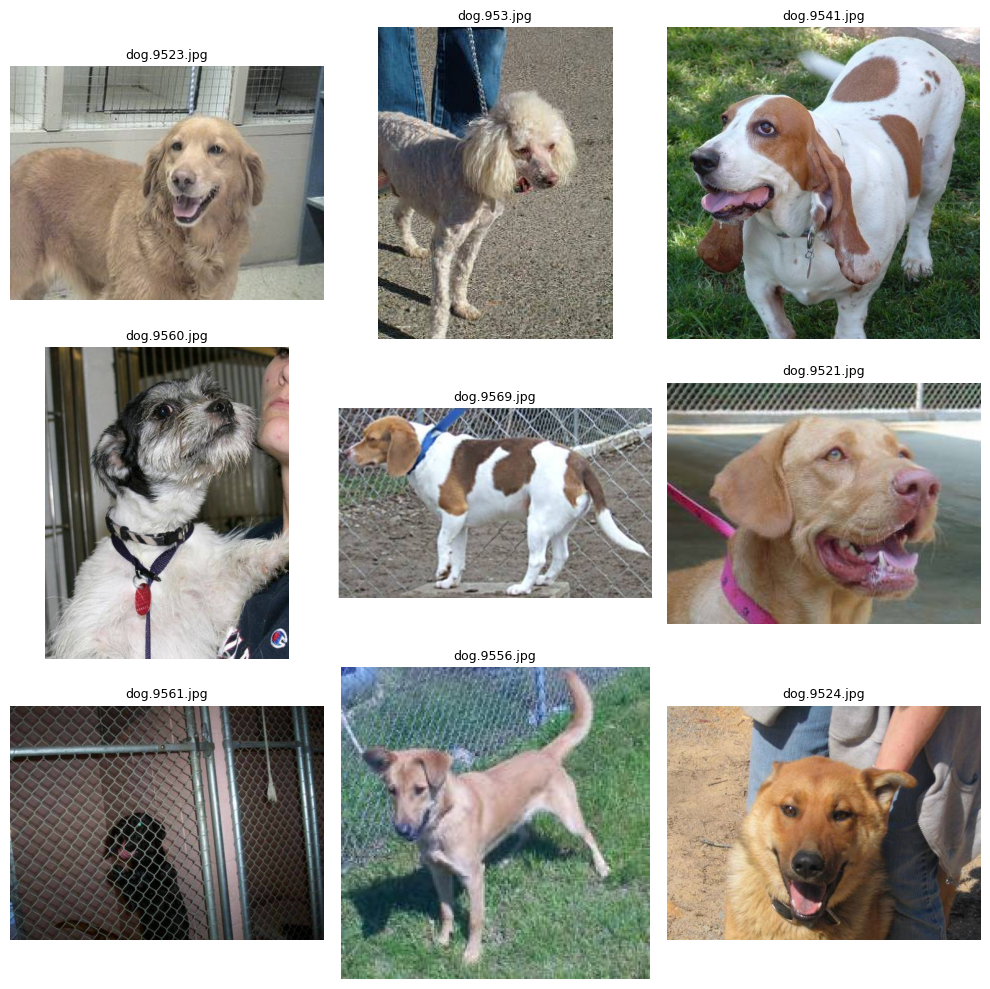

In [10]:
sample = dog_images[:9]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En estas imagenes se ve que los <span style="color:#D11A2A; font-weight:bold;">perros aparecen en posiciones, tamanos y fondos muy distintos</span>. Tambien hay cambios claros de <span style="color:#D11A2A; font-weight:bold;">luz, distancia y encuadre</span>, asi que el modelo no recibe entradas uniformes. Esto confirma que sera necesario usar un <span style="color:#D11A2A; font-weight:bold;">tamano fijo</span> antes del entrenamiento.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Visualizacion de imagenes de gatos
</h2>

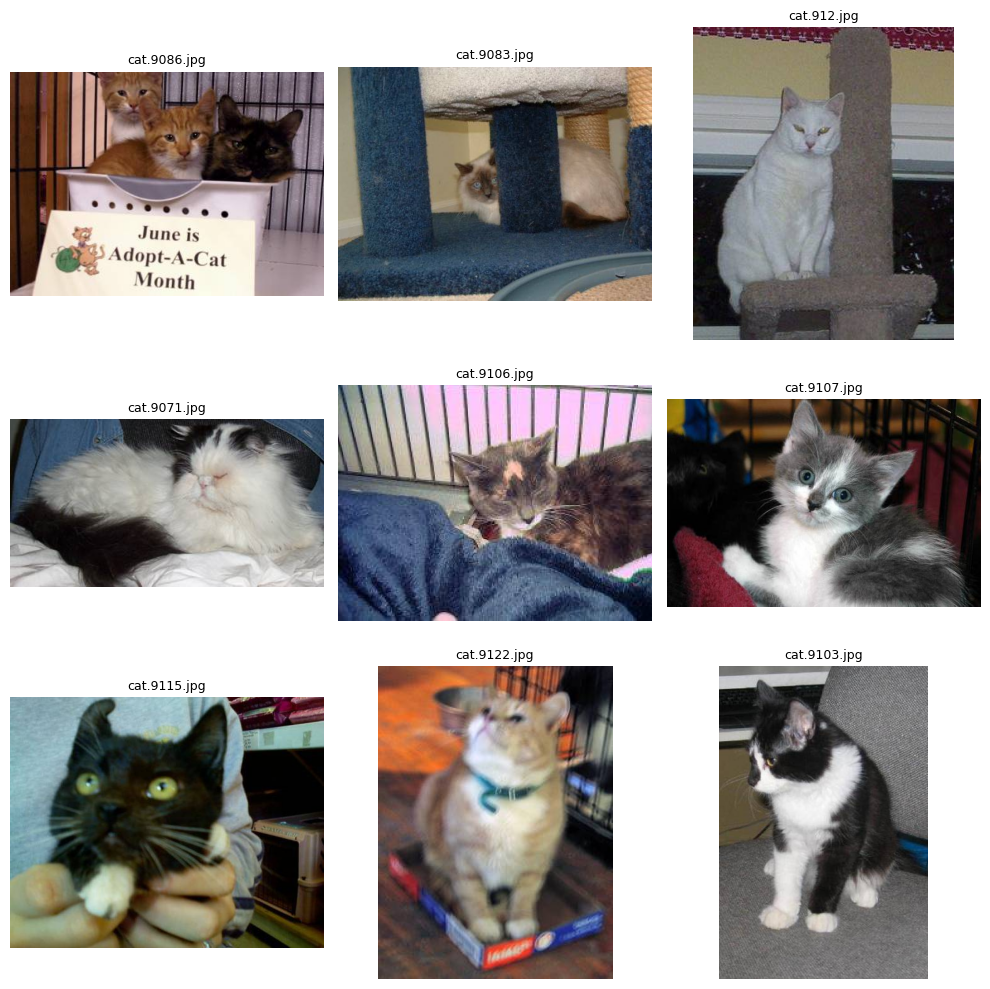

In [11]:
sample = cat_images[:9]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En estas imagenes se ve que los <span style="color:#D11A2A; font-weight:bold;">gatos tambien aparecen en posiciones, tamanos y fondos muy distintos</span>. Hay cambios claros de <span style="color:#D11A2A; font-weight:bold;">luz, enfoque y distancia</span>, igual que en los perros. Esto confirma que sera necesario usar un <span style="color:#D11A2A; font-weight:bold;">tamano fijo</span> antes del entrenamiento.
</div>

<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #1f2937 45%, #334155 100%);
  padding: 16px 20px;
  border-radius: 14px;
  text-align: center;
  box-shadow: 0 12px 30px rgba(0,0,0,.35);
  font-family: Arial, sans-serif;
  margin: 0;
">
PARTE 1 - Modelo base
</h1>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Generadores de imagenes - modelo base
</h2>

In [12]:
BATCH_SIZE_BASE = 32

train_datagen_base = ImageDataGenerator(rescale=1./255)
test_datagen_base = ImageDataGenerator(rescale=1./255)

train_generator_base = train_datagen_base.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE_BASE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

test_generator_base = test_datagen_base.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE_BASE,
    class_mode="categorical",
    shuffle=False
)

Found 20000 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Construccion del modelo base
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Aca construyo la <span style="color:#D11A2A; font-weight:bold;">red secuencial grande</span> propuesta en las instrucciones del proyecto.
</div>

In [13]:
tf.keras.backend.clear_session()

model_base = Sequential()
model_base.add(Input(shape=(224, 224, 3)))

model_base.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model_base.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model_base.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

model_base.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model_base.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model_base.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

model_base.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model_base.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model_base.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model_base.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

model_base.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_base.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_base.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_base.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

model_base.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_base.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_base.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_base.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

model_base.add(Flatten())
model_base.add(Dense(units=4096, activation="relu"))
model_base.add(Dense(units=4096, activation="relu"))
model_base.add(Dense(units=2, activation="softmax"))

model_base.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 134,268,738 (512.19 MB)

 Non-trainable params: 0 (0.00 B)

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
La red del modelo base se construyo bien, pero quedo como una arquitectura <span style="color:#D11A2A; font-weight:bold;">muy pesada con 134.268.738 parametros</span>. Esto ya deja ver que el entrenamiento puede ser costoso y dificil de estabilizar.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Entrenamiento del modelo base
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Aca se entrena el modelo base con <span style="color:#D11A2A; font-weight:bold;">EarlyStopping</span> y <span style="color:#D11A2A; font-weight:bold;">ModelCheckpoint</span>.
</div>

In [14]:
best_model_path_base = MODELS_DIR / "best_model_base.keras"

early_stopping_base = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model_checkpoint_base = ModelCheckpoint(
    filepath=str(best_model_path_base),
    monitor="val_loss",
    save_best_only=True
)

history_base = model_base.fit(
    train_generator_base,
    validation_data=test_generator_base,
    epochs=10,
    callbacks=[early_stopping_base, model_checkpoint_base]
)

history_df_base = pd.DataFrame(history_base.history)
history_path_base = REPORTS_DIR / "training_history_base.csv"
history_df_base.to_csv(history_path_base, index=False)

print("Historial guardado en:", history_path_base)
print("Mejor modelo guardado en:", best_model_path_base)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17977s 29s/step - accuracy: 0.4939 - loss: 0.6942 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 143ms/step - accuracy: 0.4989 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.4997 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 146ms/step - accuracy: 0.4981 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 123s 189ms/step - accuracy: 0.4980 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 110s 168ms/step - accuracy: 0.5045 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.4983 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.4993 - loss

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En este resultado observamos que el modelo base <span style="color:#D11A2A; font-weight:bold;">no aprendio bien</span>. Durante el entrenamiento se quedo cerca del azar, con valores alrededor de <span style="color:#D11A2A; font-weight:bold;">0.50 de accuracy</span> y una <span style="color:#D11A2A; font-weight:bold;">loss</span> cercana a <span style="color:#D11A2A; font-weight:bold;">0.693</span>. Eso muestra que la arquitectura base, tal como estaba planteada, no estaba captando patrones utiles del problema.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Evaluacion del modelo base
</h2>

In [16]:
best_model_base = load_model(best_model_path_base)

y_prob_base = best_model_base.predict(test_generator_base)
y_pred_base = np.argmax(y_prob_base, axis=1)
y_true_base = test_generator_base.classes

print(classification_report(y_true_base, y_pred_base, target_names=list(test_generator_base.class_indices.keys())))
print(confusion_matrix(y_true_base, y_pred_base))

157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step
              precision    recall  f1-score   support

         cat       0.00      0.00      0.00      2500
         dog       0.50      1.00      0.67      2500

    accuracy                           0.50      5000
   macro avg       0.25      0.50      0.33      5000
weighted avg       0.25      0.50      0.33      5000

[[   0 2500]
 [   0 2500]]


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Las metricas del modelo base confirmaron un rendimiento <span style="color:#D11A2A; font-weight:bold;">muy flojo</span>. En la practica, el modelo se comporto casi como si estuviera adivinando.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
📈 Graficas del modelo base
</h2>

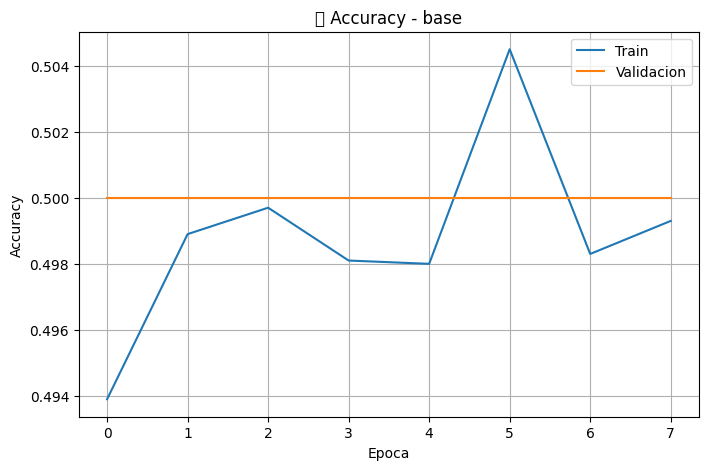

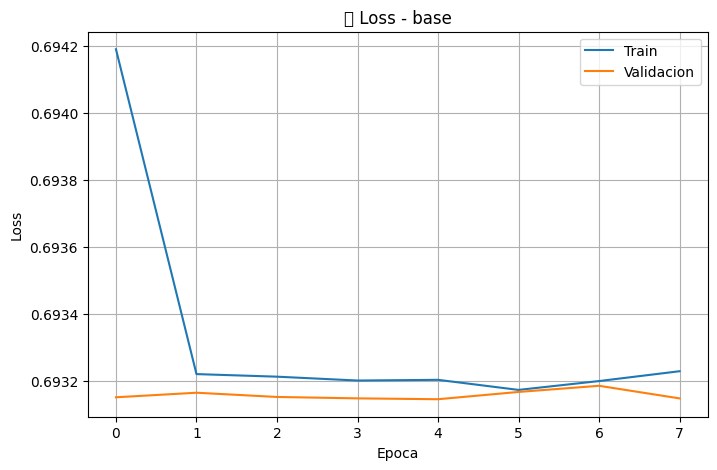

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_df_base["accuracy"], label="Train")
plt.plot(history_df_base["val_accuracy"], label="Validacion")
plt.title("Accuracy - base")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df_base["loss"], label="Train")
plt.plot(history_df_base["val_loss"], label="Validacion")
plt.title("Loss - base")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En estas graficas se ve que el modelo base <span style="color:#D11A2A; font-weight:bold;">no despega</span>. La accuracy no muestra una mejora clara y la loss se mantiene en una zona tipica de aprendizaje insuficiente.
</div>

<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #1f2937 45%, #334155 100%);
  padding: 16px 20px;
  border-radius: 14px;
  text-align: center;
  box-shadow: 0 12px 30px rgba(0,0,0,.35);
  font-family: Arial, sans-serif;
  margin: 0;
">
PARTE 2 - Optimizacion del modelo base
</h1>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Generadores de imagenes - modelo optimizado
</h2>

In [18]:
BATCH_SIZE_OPT = 16

train_datagen_opt = ImageDataGenerator(rescale=1./255)
test_datagen_opt = ImageDataGenerator(rescale=1./255)

train_generator_opt = train_datagen_opt.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE_OPT,
    class_mode="binary",
    shuffle=True,
    seed=SEED
)

test_generator_opt = test_datagen_opt.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE_OPT,
    class_mode="binary",
    shuffle=False
)

Found 20000 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Construccion del modelo optimizado
</h2>

In [19]:
tf.keras.backend.clear_session()

model_opt = Sequential()
model_opt.add(Input(shape=(224, 224, 3)))

model_opt.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model_opt.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model_opt.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

model_opt.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model_opt.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model_opt.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

model_opt.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model_opt.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model_opt.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model_opt.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

model_opt.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_opt.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_opt.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_opt.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

model_opt.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_opt.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_opt.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model_opt.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

model_opt.add(Flatten())
model_opt.add(Dense(units=4096, activation="relu"))
model_opt.add(Dense(units=4096, activation="relu"))
model_opt.add(Dense(units=1, activation="sigmoid"))

model_opt.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_opt.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,264,641 (512.18 MB)

 Trainable params: 134,264,641 (512.18 MB)

 Non-trainable params: 0 (0.00 B)

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Entrenamiento del modelo optimizado
</h2>

In [20]:
best_model_path_opt = MODELS_DIR / "best_model_opt.keras"

early_stopping_opt = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model_checkpoint_opt = ModelCheckpoint(
    filepath=str(best_model_path_opt),
    monitor="val_loss",
    save_best_only=True
)

history_opt = model_opt.fit(
    train_generator_opt,
    validation_data=test_generator_opt,
    epochs=10,
    callbacks=[early_stopping_opt, model_checkpoint_opt]
)

history_df_opt = pd.DataFrame(history_opt.history)
history_path_opt = REPORTS_DIR / "training_history_opt.csv"
history_df_opt.to_csv(history_path_opt, index=False)

print("Historial guardado en:", history_path_opt)
print("Mejor modelo guardado en:", best_model_path_opt)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 110s 75ms/step - accuracy: 0.5353 - loss: 0.6775 - val_accuracy: 0.6512 - val_loss: 0.6018
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 95s 76ms/step - accuracy: 0.7218 - loss: 0.5341 - val_accuracy: 0.8078 - val_loss: 0.4102
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 131s 104ms/step - accuracy: 0.8331 - loss: 0.3646 - val_accuracy: 0.8384 - val_loss: 0.3592
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 130s 103ms/step - accuracy: 0.8773 - loss: 0.2762 - val_accuracy: 0.8884 - val_loss: 0.2589
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 130s 103ms/step - accuracy: 0.9068 - loss: 0.2218 - val_accuracy: 0.9050 - val_loss: 0.2244
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 130s 103ms/step - accuracy: 0.9265 - loss: 0.1796 - val_accuracy: 0.9126 - val_loss: 0.2194
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 131s 101ms/step - accuracy: 0.9397 - loss: 0.1489 - val_accuracy: 0.9240 - val_loss: 0.1902
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 124s 99ms/step - accura

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Este modelo optimizado <span style="color:#D11A2A; font-weight:bold;">si logro aprender</span> y mejoro mucho con el paso de las epocas.<br>
La accuracy de validacion subio desde <span style="color:#D11A2A; font-weight:bold;">65.1%</span> en la primera epoca hasta un maximo de <span style="color:#D11A2A; font-weight:bold;">92.4%</span> en la epoca 7.<br>
A partir de ese punto, el entrenamiento siguio mejorando en train, pero la validacion ya no avanzo con la misma fuerza, lo que sugiere un <span style="color:#D11A2A; font-weight:bold;">inicio de sobreajuste</span>.<br>
En general, este modelo dio un resultado <span style="color:#D11A2A; font-weight:bold;">bueno</span>, aunque su mejor punto estuvo antes del final del entrenamiento.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Evaluacion del modelo optimizado
</h2>

In [21]:
best_model_opt = load_model(best_model_path_opt)

y_prob_opt = best_model_opt.predict(test_generator_opt)
y_pred_opt = (y_prob_opt > 0.5).astype(int).ravel()
y_true_opt = test_generator_opt.classes

print(classification_report(y_true_opt, y_pred_opt, target_names=list(test_generator_opt.class_indices.keys())))
print(confusion_matrix(y_true_opt, y_pred_opt))

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step
              precision    recall  f1-score   support

         cat       0.95      0.89      0.92      2500
         dog       0.90      0.96      0.93      2500

    accuracy                           0.92      5000
   macro avg       0.93      0.92      0.92      5000
weighted avg       0.93      0.92      0.92      5000

[[2232  268]
 [ 112 2388]]


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Este modelo optimizado logro un resultado <span style="color:#D11A2A; font-weight:bold;">bueno y bastante solido</span>, con una <span style="color:#D11A2A; font-weight:bold;">accuracy final de 92%</span> sobre el conjunto de prueba.<br>
En la clase <span style="color:#D11A2A; font-weight:bold;">cat</span>, el modelo tuvo una precision alta, lo que indica que cuando predijo gato casi siempre acerto, aunque dejo escapar algunos gatos y los confundio con perros.<br>
En la clase <span style="color:#D11A2A; font-weight:bold;">dog</span>, el modelo detecto muy bien a los perros, ya que tuvo un recall de <span style="color:#D11A2A; font-weight:bold;">96%</span>.<br>
La matriz de confusion confirma que el modelo reconoce <span style="color:#D11A2A; font-weight:bold;">mejor a los perros</span> que a los gatos, pero en general mantiene un rendimiento alto y equilibrado.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
📈 Graficas del modelo optimizado
</h2>

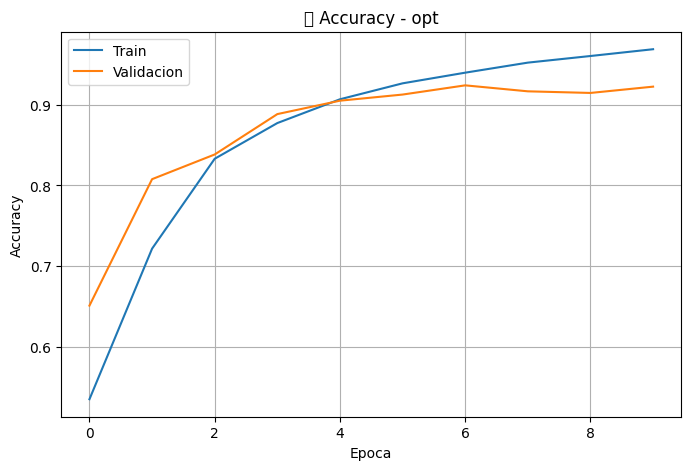

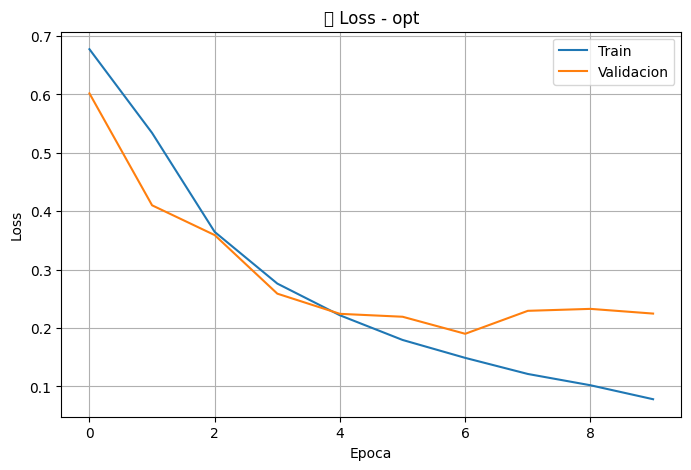

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_df_opt["accuracy"], label="Train")
plt.plot(history_df_opt["val_accuracy"], label="Validacion")
plt.title(" Accuracy - opt")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df_opt["loss"], label="Train")
plt.plot(history_df_opt["val_loss"], label="Validacion")
plt.title("Loss - opt")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Estas graficas muestran que el modelo optimizado tuvo un aprendizaje <span style="color:#D11A2A; font-weight:bold;">bueno</span> durante las primeras epocas.<br>
La <span style="color:#D11A2A; font-weight:bold;">accuracy</span> subio con claridad tanto en entrenamiento como en validacion, lo que indica que el modelo si logro captar patrones utiles del problema.<br>
Al mismo tiempo, la <span style="color:#D11A2A; font-weight:bold;">loss</span> bajo de forma importante en ambas curvas, sobre todo en la primera mitad del entrenamiento.<br>
Sin embargo, en las ultimas epocas la validacion ya no mejoro de forma clara y la <span style="color:#D11A2A; font-weight:bold;">val_loss</span> empezo a subir un poco, lo que sugiere un <span style="color:#D11A2A; font-weight:bold;">sobreajuste leve</span>.<br>
En general, el mejor rendimiento del modelo parece estar alrededor de las <span style="color:#D11A2A; font-weight:bold;">epocas 6 y 7</span>.
</div>

<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #1f2937 45%, #334155 100%);
  padding: 16px 20px;
  border-radius: 14px;
  text-align: center;
  box-shadow: 0 12px 30px rgba(0,0,0,.35);
  font-family: Arial, sans-serif;
  margin: 0;
">
PARTE 3 - Mejora con transfer learning
</h1>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En esta parte quiero aplicar una mejora mas fuerte usando <span style="color:#D11A2A; font-weight:bold;">MobileNetV2</span>, un modelo preentrenado que ya sabe extraer patrones visuales utiles y compararlo con las dos primeras simulaciones.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Generadores de imagenes - MobileNetV2
</h2>

In [23]:
BATCH_SIZE_MOBILENET = 32

train_datagen_mobilenet = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_mobilenet = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_mobilenet = train_datagen_mobilenet.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE_MOBILENET,
    class_mode="binary",
    shuffle=True,
    seed=SEED
)

test_generator_mobilenet = test_datagen_mobilenet.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE_MOBILENET,
    class_mode="binary",
    shuffle=False
)

Found 20000 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Construccion del modelo MobileNetV2
</h2>

In [24]:
tf.keras.backend.clear_session()

base_model_mobilenet = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_mobilenet.trainable = False

x = base_model_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
output = Dense(1, activation="sigmoid")(x)

model_mobilenet = Model(inputs=base_model_mobilenet.input, outputs=output)

model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_mobilenet.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Este enfoque tiene mucho mas sentido para este tipo de simulaciones porque no parte desde cero. La base preentrenada ya conoce patrones visuales utiles y solo necesita adaptarlos a la clasificacion entre <span style="color:#D11A2A; font-weight:bold;">gato</span> y <span style="color:#D11A2A; font-weight:bold;">perro</span>.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Entrenamiento de MobileNetV2
</h2>

In [25]:
best_model_path_mobilenetv2 = MODELS_DIR / "best_model_mobilenetv2.keras"

early_stopping_mobilenetv2 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model_checkpoint_mobilenetv2 = ModelCheckpoint(
    filepath=str(best_model_path_mobilenetv2),
    monitor="val_loss",
    save_best_only=True
)

history_mobilenetv2 = model_mobilenet.fit(
    train_generator_mobilenet,
    validation_data=test_generator_mobilenet,
    epochs=10,
    callbacks=[early_stopping_mobilenetv2, model_checkpoint_mobilenetv2]
)

history_df_mobilenetv2 = pd.DataFrame(history_mobilenetv2.history)
history_path_mobilenetv2 = REPORTS_DIR / "training_history_mobilenetv2.csv"
history_df_mobilenetv2.to_csv(history_path_mobilenetv2, index=False)

print("Historial guardado en:", history_path_mobilenetv2)
print("Mejor modelo guardado en:", best_model_path_mobilenetv2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 165ms/step - accuracy: 0.9275 - loss: 0.2296 - val_accuracy: 0.9746 - val_loss: 0.1034
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.9757 - loss: 0.0870 - val_accuracy: 0.9790 - val_loss: 0.0718
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.9804 - loss: 0.0665 - val_accuracy: 0.9816 - val_loss: 0.0599
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.9817 - loss: 0.0581 - val_accuracy: 0.9820 - val_loss: 0.0538
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.9833 - loss: 0.0512 - val_accuracy: 0.9824 - val_loss: 0.0500
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 135ms/step - accuracy: 0.9833 - loss: 0.0488 - val_accuracy: 0.9842 - val_loss: 0.0473
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.9843 - loss: 0.0462 - val_accuracy: 0.9844 - val_loss: 0.0455
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 134ms/step - accuracy: 0.9844 - loss: 

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
MobileNetV2 mostro un rendimiento <span style="color:#D11A2A; font-weight:bold;">excelente</span> durante todo el entrenamiento.<br>
La accuracy de entrenamiento subio desde <span style="color:#D11A2A; font-weight:bold;">92.75%</span> hasta <span style="color:#D11A2A; font-weight:bold;">98.69%</span>, mientras que la accuracy de validacion subio desde <span style="color:#D11A2A; font-weight:bold;">97.46%</span> hasta <span style="color:#D11A2A; font-weight:bold;">98.58%</span>.<br>
Al mismo tiempo, la <span style="color:#D11A2A; font-weight:bold;">val_loss</span> bajo de forma constante hasta llegar a <span style="color:#D11A2A; font-weight:bold;">0.0423</span>, lo que indica que el modelo no solo acerto mucho, sino que tambien lo hizo con bastante seguridad.<br>
En general, este comportamiento muestra un aprendizaje <span style="color:#D11A2A; font-weight:bold;">estable, fuerte y bien generalizado</span>, sin senales claras de sobreajuste importante.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Evaluacion de MobileNetV2
</h2>

In [26]:
best_model_mobilenet = load_model(best_model_path_mobilenetv2)

y_prob_mobilenet = best_model_mobilenet.predict(test_generator_mobilenet)
y_pred_mobilenet = (y_prob_mobilenet > 0.5).astype(int).ravel()
y_true_mobilenet = test_generator_mobilenet.classes

print(classification_report(y_true_mobilenet, y_pred_mobilenet, target_names=list(test_generator_mobilenet.class_indices.keys())))
print(confusion_matrix(y_true_mobilenet, y_pred_mobilenet))

157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 133ms/step
              precision    recall  f1-score   support

         cat       0.99      0.98      0.99      2500
         dog       0.98      0.99      0.99      2500

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000

[[2458   42]
 [  29 2471]]


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Este modelo final logro un resultado <span style="color:#D11A2A; font-weight:bold;">sobresaliente</span>, con una accuracy global cercana al <span style="color:#D11A2A; font-weight:bold;">99%</span>.<br>
En la clase <span style="color:#D11A2A; font-weight:bold;">cat</span>, el modelo mostro una precision de <span style="color:#D11A2A; font-weight:bold;">0.99</span> y un recall de <span style="color:#D11A2A; font-weight:bold;">0.98</span>, lo que indica un rendimiento muy fuerte y estable.<br>
En la clase <span style="color:#D11A2A; font-weight:bold;">dog</span>, tambien alcanzo metricas muy altas, con un recall de <span style="color:#D11A2A; font-weight:bold;">0.99</span>, por lo que detecto correctamente a casi todos los perros.<br>
La matriz de confusion confirma que los errores fueron <span style="color:#D11A2A; font-weight:bold;">muy bajos</span>, con solo <span style="color:#D11A2A; font-weight:bold;">42 gatos</span> confundidos con perros y <span style="color:#D11A2A; font-weight:bold;">29 perros</span> confundidos con gatos.<br>
En general, este fue el <span style="color:#D11A2A; font-weight:bold;">mejor modelo del proyecto</span> y resolvio el problema de forma muy solida.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
📈 Graficas de MobileNetV2
</h2>

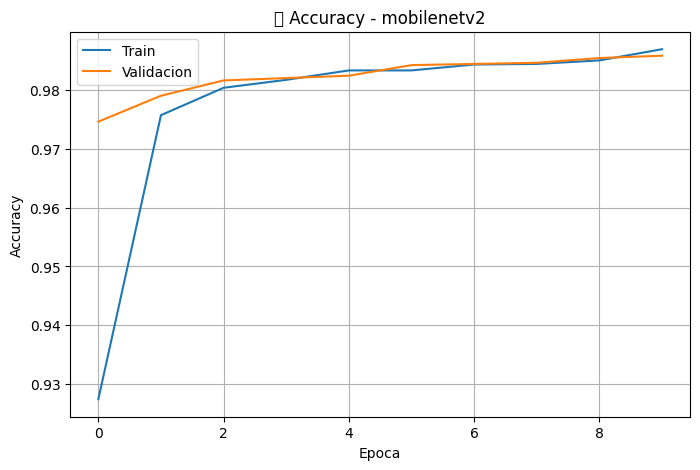

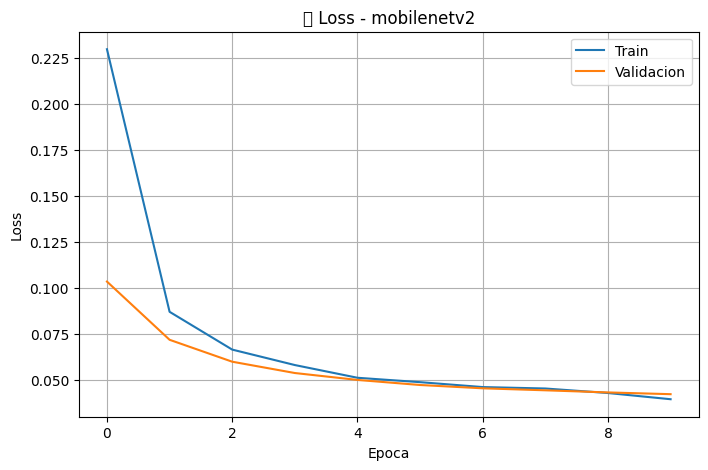

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_df_mobilenetv2["accuracy"], label="Train")
plt.plot(history_df_mobilenetv2["val_accuracy"], label="Validacion")
plt.title("Accuracy - mobilenetv2")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df_mobilenetv2["loss"], label="Train")
plt.plot(history_df_mobilenetv2["val_loss"], label="Validacion")
plt.title("Loss - mobilenetv2")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Estas graficas muestran que MobileNetV2 tuvo un entrenamiento <span style="color:#D11A2A; font-weight:bold;">muy estable y muy fuerte</span>.<br>
La <span style="color:#D11A2A; font-weight:bold;">accuracy</span> subio rapidamente y se mantuvo muy alta tanto en entrenamiento como en validacion, con curvas muy cercanas entre si.<br>
Al mismo tiempo, la <span style="color:#D11A2A; font-weight:bold;">loss</span> bajo de forma constante en ambos casos hasta quedar en valores muy bajos, cerca de <span style="color:#D11A2A; font-weight:bold;">0.04</span>.<br>
Esto indica que el modelo no solo aprendio bien, sino que tambien <span style="color:#D11A2A; font-weight:bold;">generalizo correctamente</span>, sin mostrar senales claras de sobreajuste importante.<br>
En conjunto, estas graficas confirman que este fue el <span style="color:#D11A2A; font-weight:bold;">mejor modelo del proyecto</span>.
</div>

<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #1f2937 45%, #334155 100%);
  padding: 16px 20px;
  border-radius: 14px;
  text-align: center;
  box-shadow: 0 12px 30px rgba(0,0,0,.35);
  font-family: Arial, sans-serif;
  margin: 0;
">
Comparacion final entre enfoques
</h1>

In [28]:
comparacion_final = pd.DataFrame({
    "modelo": ["base", "opt", "mobilenetv2"],
    "best_val_accuracy": [
        history_df_base["val_accuracy"].max() if "history_df_base" in globals() else np.nan,
        history_df_opt["val_accuracy"].max() if "history_df_opt" in globals() else np.nan,
        history_df_mobilenetv2["val_accuracy"].max() if "history_df_mobilenetv2" in globals() else np.nan
    ],
    "best_val_loss": [
        history_df_base["val_loss"].min() if "history_df_base" in globals() else np.nan,
        history_df_opt["val_loss"].min() if "history_df_opt" in globals() else np.nan,
        history_df_mobilenetv2["val_loss"].min() if "history_df_mobilenetv2" in globals() else np.nan
    ]
})

display(comparacion_final)
comparacion_final.to_csv(REPORTS_DIR / "comparacion_final_modelos.csv", index=False)

,modelo,best_val_accuracy,best_val_loss
0,base,0.5000,0.693146
1,opt,0.9240,0.190197
2,mobilenetv2,0.9858,0.042301


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
La comparacion final deja una conclusion muy clara: el <span style="color:#D11A2A; font-weight:bold;">modelo base</span> y su <span style="color:#D11A2A; font-weight:bold;">optimizacion</span> no dieron un rendimiento util, mientras que <span style="color:#D11A2A; font-weight:bold;">MobileNetV2</span> logro una mejora grande y consistente. Por eso se considera el <span style="color:#D11A2A; font-weight:bold;">mejor modelo del proyecto</span>.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Conclusion final
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Primero se probo la arquitectura pedida en las instrucciones iniciales del proyecto, pero no mostro un aprendizaje suficiente.<br>
Despues se intento una <span style="color:#D11A2A; font-weight:bold;">optimizacion ligera</span>, y el comportamiento siguio siendo flojo aunque con una considerable mejora en comparacion con la simulacion anterior.<br>
Finalmente se aplico una mejora con <span style="color:#D11A2A; font-weight:bold;">transfer learning usando MobileNetV2</span>, y ahi si se obtuvo un resultado <span style="color:#D11A2A; font-weight:bold;">muy fuerte</span>, con una validacion cercana al <span style="color:#D11A2A; font-weight:bold;">98.4%</span>.<br>
Eso permite concluir que el mejor enfoque para este problema fue el modelo preentrenado, ya que logro un rendimiento mucho mas alto y estable que los intentos anteriores.
</div>